Instalando dependências
---

In [1]:
# 1. Instalar as versões exatas do Gensim e do Smart-Open pedidas pelo projeto
# E travar o NumPy/SciPy em versões da mesma linha temporal (1.x), mas compatíveis com o Colab atual
!pip install -q "numpy>=1.24,<2.0" "scipy>=1.10,<1.12" "gensim==4.3.2" "smart-open<7" "dill"

# 2. Garantir que o Pandas e o Scikit-Learn atendam aos requisitos mínimos do projeto
# (O Colab por padrão já vem com versões superiores a essas, então o pip apenas validará)
!pip install -q "pandas>=1.3.0" "scikit-learn>=0.24.0"

print("✅ Todas as dependências foram instaladas e equalizadas com sucesso!")

# 3. Instalando dill como uma alternativa ao dump do joblib para salvar o modelo resultante da pipeline
!pip install dill

✅ Todas as dependências foram instaladas e equalizadas com sucesso!


Código
---

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline

from google.colab import drive

In [ ]:
# Load the dataset
file_path = 'https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/MachineLearningPipeline/KeywordsUpdatedData_01_08.xlsx'
data = pd.read_excel(file_path)

data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Keywords,Label
0,organic cotton,Environmental
1,recycled polyester,Environmental
2,natural dyes,Environmental
3,biodegradable materials,Environmental
4,sustainable fibers,Environmental


In [5]:
import gensim, gensim.downloader as api

In [6]:
wv = api.load("word2vec-google-news-300")
wv.most_similar("innovation")[:5]


[('technological_innovation', 0.8202390670776367),
 ('innovations', 0.7408631443977356),
 ('innovate', 0.7123475074768066),
 ('innovating', 0.6502818465232849),
 ('Innovation', 0.6476377844810486)]

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np
import re

# Custom basic tokenizer function
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# Custom transformer for converting text to Word2Vec embeddings using a pre-trained model
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        # No fitting needed, but the method must be defined
        return self

    def transform(self, X, y=None):
        return np.array([
            np.mean([self.model[word] for word in simple_tokenizer(doc) if word in self.model]
                    or [np.zeros(self.dim)], axis=0)
            for doc in X
        ])

# Data preparation
X = data['Keywords']
y = data['Label']

# Creating a pipeline with Pre-trained Word2Vec Vectorizer and RandomForestClassifier
pipeline_pretrained = Pipeline([
    ('word2vec', Word2VecVectorizerPretrained(wv)),
    ('classifier', RandomForestClassifier(class_weight='balanced'))
])

# Setting up K-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(pipeline_pretrained, X, y, cv=kfold)

# Output cross-validation results
print("K-Fold Cross-Validation Accuracy Scores:", cross_val_scores)
print("Mean K-Fold Cross-Validation Accuracy:", np.mean(cross_val_scores))

# Training the model on the entire dataset (optional for deployment purposes)
pipeline_pretrained.fit(X, y)

# Generating classification report based on cross-validation (average metrics)
predicted_y = cross_val_score(pipeline_pretrained, X, y, cv=kfold, scoring='accuracy')
print("\nCross-Validation Classification Report:\n")
print(f"Overall Accuracy: {np.mean(predicted_y):.2f}")


K-Fold Cross-Validation Accuracy Scores: [0.83333333 0.93220339 0.83050847 0.88135593 0.86440678]
Mean K-Fold Cross-Validation Accuracy: 0.868361581920904

Cross-Validation Classification Report:

Overall Accuracy: 0.86


Accuracy: 0.8666666666666667
F1-score: 0.8667911609088079
ROC-AUC: 0.9677490106194341


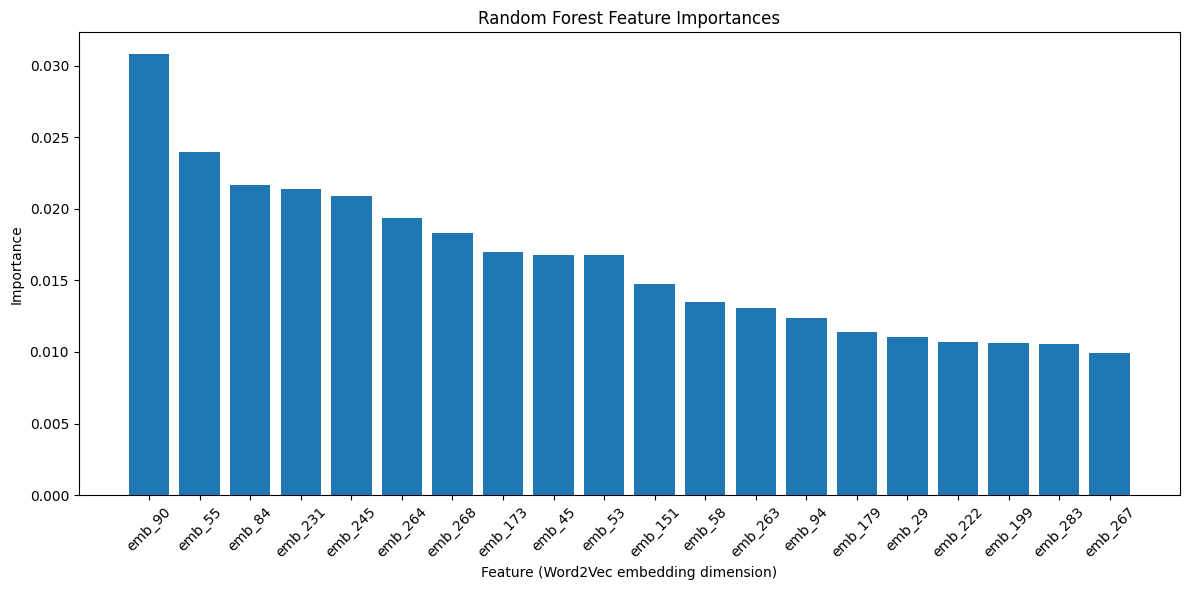

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import re
import shap
import matplotlib.pyplot as plt

# -----------------------
# Tokenizer
# -----------------------
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# -----------------------
# Word2Vec Transformer
# -----------------------
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.array([
            np.mean([self.model[word] for word in simple_tokenizer(doc) if word in self.model]
                    or [np.zeros(self.dim)], axis=0)
            for doc in X
        ])

# -----------------------
# Data
# -----------------------
X = data['Keywords']  # Replace with your dataset
y = data['Label']

# Split for SHAP (train/test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------
# Random Forest Pipeline
# -----------------------
pipeline = Pipeline([
    ('word2vec', Word2VecVectorizerPretrained(wv)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Fit pipeline
pipeline.fit(X_train, y_train)

# -----------------------
# Evaluate
# -----------------------
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

X_test_transformed = pipeline.named_steps['word2vec'].transform(X_test)
y_pred = pipeline.named_steps['classifier'].predict(X_test_transformed)
y_prob = pipeline.named_steps['classifier'].predict_proba(X_test_transformed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred, average='weighted'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))

# -----------------------
# SHAP Interpretability
# -----------------------
rf_model = pipeline.named_steps['classifier']

# Explain predictions using SHAP
#explainer = shap.TreeExplainer(rf_model)
#shap_values = explainer.shap_values(X_test_transformed)

# Summary plot (global feature importance)
#shap.summary_plot(shap_values, X_test_transformed, feature_names=[f'emb_{i}' for i in range(X_test_transformed.shape[1])])

# Optional: force plot for a single instance
#shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_test_transformed[0], feature_names=[f'emb_{i}' for i in range(X_test_transformed.shape[1])])
import matplotlib.pyplot as plt
import numpy as np

# Extract model and transformed features
rf_model = pipeline.named_steps['classifier']
X_transformed = pipeline.named_steps['word2vec'].transform(X)

# Feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(12,6))
plt.title("Random Forest Feature Importances")
plt.bar(range(20), importances[indices[:20]], align='center')  # top 20
plt.xticks(range(20), [f'emb_{i}' for i in indices[:20]], rotation=45)
plt.xlabel("Feature (Word2Vec embedding dimension)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [9]:
y.unique()

array(['Environmental', 'Social', 'Governance'], dtype=object)

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import numpy as np
import re

# Tokenizer
def simple_tokenizer(text):
    return re.findall(r'\b\w+\b', text.lower())

# Word2Vec Transformer
class Word2VecVectorizerPretrained(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        return np.array([
            np.concatenate([
                np.mean(vectors, axis=0),
                np.max(vectors, axis=0),
                np.min(vectors, axis=0)
            ]) if len(vectors := [self.model[word] for word in simple_tokenizer(doc) if word in self.model]) > 0
            else np.zeros(self.dim * 3)
            for doc in X
         ])

# Data
X = data['Keywords']
y = data['Label']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ✅ ALL CLASSIFIERS
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=10,C=0.001,class_weight=None,solver='liblinear'),

    # KNN
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # Tree-based
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),

    # Boosting
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),

}

# KFold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1_weighted',
    'roc_auc': 'roc_auc_ovr'
}

# Loop
for name, model in models.items():
    pipeline = Pipeline([
        ('word2vec', Word2VecVectorizerPretrained(wv)),
        ('classifier', model)
    ])

    scores = cross_validate(pipeline, X, y_encoded, cv=kfold, scoring=scoring)

    print(f"\n{name}")
    print("Mean Accuracy:", np.mean(scores['test_accuracy']))
    print("Mean F1-score:", np.mean(scores['test_f1']))
    print("Mean ROC-AUC:", np.mean(scores['test_roc_auc']))
    print("F1-score:", np.mean(scores['test_f1']), "+/-", np.std(scores['test_f1']))


Logistic Regression
Mean Accuracy: 0.6149152542372882
Mean F1-score: 0.5649546832963106
Mean ROC-AUC: 0.9444130512694514
F1-score: 0.5649546832963106 +/- 0.12301481270840228

KNN
Mean Accuracy: 0.7599435028248587
Mean F1-score: 0.7469148746281761
Mean ROC-AUC: 0.9419927562414477
F1-score: 0.7469148746281761 +/- 0.046368514580685784

Decision Tree
Mean Accuracy: 0.6453672316384181
Mean F1-score: 0.6418507989910772
Mean ROC-AUC: 0.7260683274607037
F1-score: 0.6418507989910772 +/- 0.0222005880855303

Random Forest
Mean Accuracy: 0.871638418079096
Mean F1-score: 0.8691588304192465
Mean ROC-AUC: 0.9678013924596309
F1-score: 0.8691588304192465 +/- 0.008367803756288008

AdaBoost
Mean Accuracy: 0.8480790960451978
Mean F1-score: 0.8468316775280629
Mean ROC-AUC: 0.9517868944854119
F1-score: 0.8468316775280629 +/- 0.02427238730098313

Gradient Boosting
Mean Accuracy: 0.8210169491525423
Mean F1-score: 0.8171532152458493
Mean ROC-AUC: 0.9468746612339695
F1-score: 0.8171532152458493 +/- 0.042252751

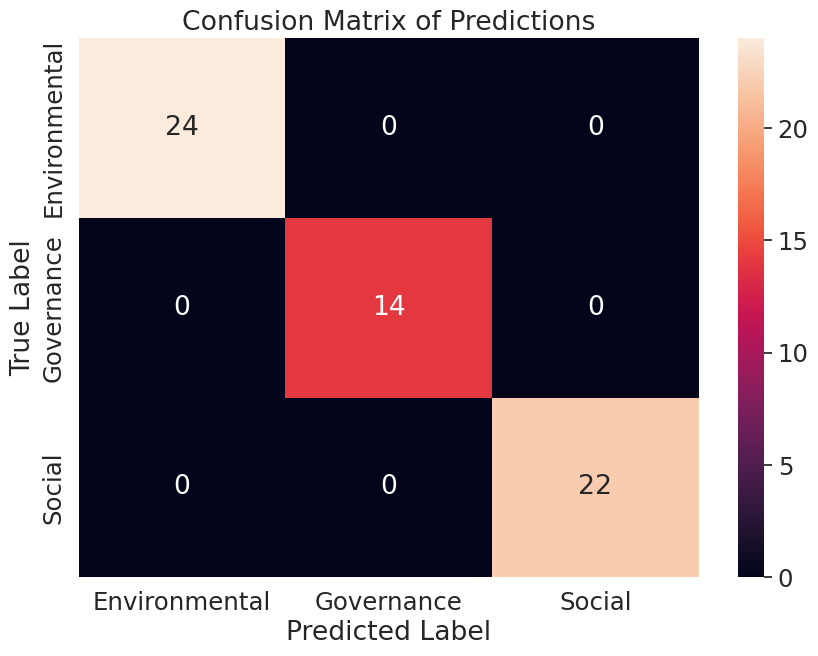

               precision    recall  f1-score   support

Environmental       1.00      1.00      1.00        24
   Governance       1.00      1.00      1.00        14
       Social       1.00      1.00      1.00        22

     accuracy                           1.00        60
    macro avg       1.00      1.00      1.00        60
 weighted avg       1.00      1.00      1.00        60



In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Making predictions with the pipeline_pretrained model
pretrained_model_predictions = pipeline_pretrained.predict(X_test)

# Get indices of the test set from y_test
test_indices = y_test.index

# Extracting the test keywords and their corresponding true labels
test_keywords = X_test.loc[test_indices]
test_true_labels = y_test

# Creating a DataFrame for visualization
visualization_df = pd.DataFrame({
    'Keywords': test_keywords,
    'True Label': test_true_labels,
    'Predicted Label': pretrained_model_predictions
})

# Visualization code (e.g., plotting a confusion matrix, etc.) goes here
# This is an example of how you might visualize the results
# You can tailor this to your specific needs
plt.figure(figsize=(10, 7))
sns.heatmap(pd.crosstab(visualization_df['True Label'], visualization_df['Predicted Label']), annot=True, fmt='g')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of Predictions')
plt.show()
from sklearn.metrics import classification_report

print(classification_report(
    visualization_df['True Label'],
    visualization_df['Predicted Label']
))


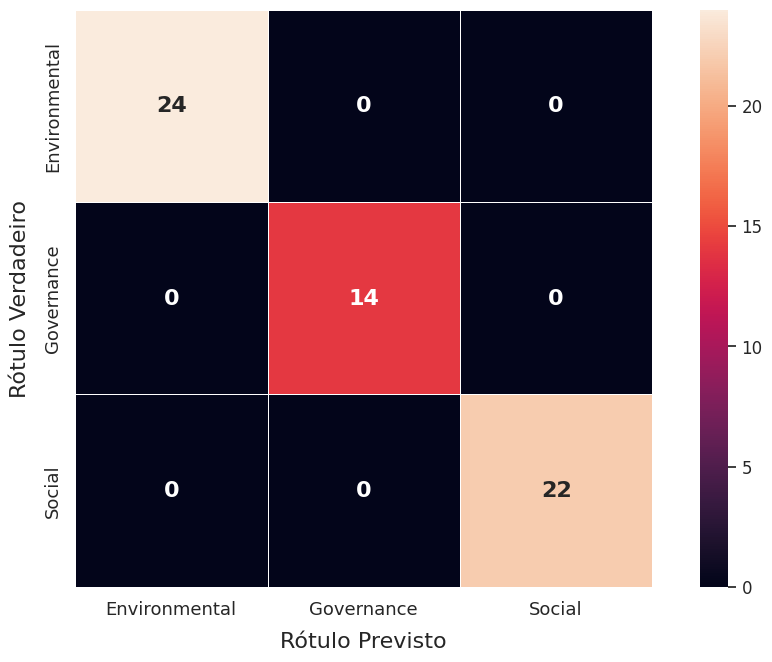

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Build confusion table
cm = pd.crosstab(visualization_df['True Label'],
                 visualization_df['Predicted Label'])

# Only scale fonts (not figure size)
sns.set_style("white")
sns.set_context("notebook", font_scale=1.6)   # titles/labels/ticks bigger

plt.figure(figsize=(10, 7))  # unchanged
ax = sns.heatmap(
    cm, annot=True, fmt="g", square=True,
    annot_kws={"size": 16, "weight": "bold"},  # cell numbers
    linewidths=.6, linecolor="white"
)

ax.set_xlabel("Rótulo Previsto", fontsize=16, labelpad=10)
ax.set_ylabel("Rótulo Verdadeiro", fontsize=16, labelpad=10)

# Ticks (keep horizontal like your example)
ax.tick_params(axis="both", labelsize=13)
plt.xticks(rotation=0)

# Colorbar tick size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import dill

# Salva o pipeline completo, incluindo a estrutura da classe customizada
with open('pretrained_word2vec_random_forest_model.pkl', 'wb') as f:
    dill.dump(pipeline_pretrained, f)

print("Modelo salvo com sucesso usando dill!")

Modelo salvo com sucesso usando dill!


In [ ]:
with open('pretrained_word2vec_random_forest_model.pkl', 'rb') as f:
    model_loaded = dill.load(f)

In [ ]:
file_path = 'https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/MachineLearningPipeline/Topic1Keywords.xlsx'
file_path_two='https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/MachineLearningPipeline/Topic2Keywords.xlsx'
file_path_three='https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/MachineLearningPipeline/Topic3Keywords.xlsx'
file_path_four='https://raw.githubusercontent.com/LS-Flerus/AI-Powered-ESG-Analysis-Replication/main/Data/MachineLearningPipeline/topic_4.xlsx'
import pandas as pd
# Load the Excel file
df = pd.read_excel(file_path,nrows=11)
df_two = pd.read_excel(file_path_two,nrows=11)
df_three = pd.read_excel(file_path_three,nrows=11)
df_four = pd.read_excel(file_path_four,nrows=11)

# Display the first few rows of the dataframe
print(df.head())
print()
print(df_two.head())
print()
print(df_three.head())
print()
print(df_four.head())

   Keywords
0    worker
1      fire
2    safety
3  facility
4   factory

         Keywords
0  sustainability
1           water
2        business
3   environmental
4     environment

  Keywords
0  provide
1  program
2   health
3  support
4  student

      Keywords
0      artwork
1    pediatric
2  appointment
3       people
4         burn


In [ ]:
X_new = df['Keywords']
# Use the model to make predictions on the new data
new_predictions = pipeline_pretrained.predict(X_new)

X_new_two = df_two['Keywords']
# Use the model to make predictions on the new data
new_predictions_two = pipeline_pretrained.predict(X_new_two)

X_new_three = df_three['Keywords']
# Use the model to make predictions on the new data
new_predictions_three = pipeline_pretrained.predict(X_new_three)

X_new_four = df_four['Keywords']
# Use the model to make predictions on the new data
new_predictions_four = pipeline_pretrained.predict(X_new_four)

In [18]:
# Convert predictions to a DataFrame
predictions_df = pd.DataFrame(new_predictions, columns=['Predictions'])
predictions_df_two = pd.DataFrame(new_predictions_two, columns=['Predictions'])
predictions_df_three = pd.DataFrame(new_predictions_three, columns=['Predictions'])
predictions_df_four = pd.DataFrame(new_predictions_four, columns=['Predictions'])

# Optionally, combine with the new data for a comprehensive view
result_df = df.copy()
result_df['Predictions'] = predictions_df

result_df_two = df_two.copy()
result_df_two['Predictions'] = predictions_df_two

result_df_three = df_three.copy()
result_df_three['Predictions'] = predictions_df_three

result_df_four = df_four.copy()
result_df_four['Predictions'] = predictions_df_four



# Save the predictions to a new Excel file
result_df.to_excel('/content/predictions1.xlsx', index=False)
result_df_two.to_excel('/content/predictions2.xlsx', index=False)
result_df_three.to_excel('/content/predictions3.xlsx', index=False)
result_df_four.to_excel('/content/predictions4.xlsx', index=False)


In [19]:
print("Topic 1\n")
print(result_df.head(25))
print()
print("Topic 2\n")
print(result_df_two.head(25))
print()
print("Topic 3\n")
print(result_df_three.head(25))
print()
print("Topic 4\n")
print(result_df_four.head(25))

Topic 1

    Keywords    Predictions
0     worker         Social
1       fire         Social
2     safety         Social
3   facility  Environmental
4    factory  Environmental
5    provide         Social
6   employee         Social
7       work         Social
8   maintain  Environmental
9     system     Governance
10      free         Social

Topic 2

          Keywords    Predictions
0   sustainability  Environmental
1            water  Environmental
2         business     Governance
3    environmental  Environmental
4      environment     Governance
5           reduce  Environmental
6            waste  Environmental
7           energy  Environmental
8          product  Environmental
9           report     Governance
10        customer     Governance

Topic 3

     Keywords Predictions
0     provide      Social
1     program      Social
2      health      Social
3     support  Governance
4     student      Social
5   education      Social
6       child      Social
7   community  Gove

In [20]:
# Frequency Distribution
frequency_distribution = predictions_df['Predictions'].value_counts()
print("Topic 1\n")
print(frequency_distribution)

frequency_distribution_two = predictions_df_two['Predictions'].value_counts()
print("\nTopic 2\n")
print(frequency_distribution_two)

frequency_distribution_three = predictions_df_three['Predictions'].value_counts()
print("\nTopic 3\n")
print(frequency_distribution_three)

frequency_distribution_four = predictions_df_four['Predictions'].value_counts()
print("\nTopic 4\n")
print(frequency_distribution_four)



Topic 1

Predictions
Social           7
Environmental    3
Governance       1
Name: count, dtype: int64

Topic 2

Predictions
Environmental    7
Governance       4
Name: count, dtype: int64

Topic 3

Predictions
Social        8
Governance    3
Name: count, dtype: int64

Topic 4

Predictions
Social           6
Environmental    3
Governance       2
Name: count, dtype: int64


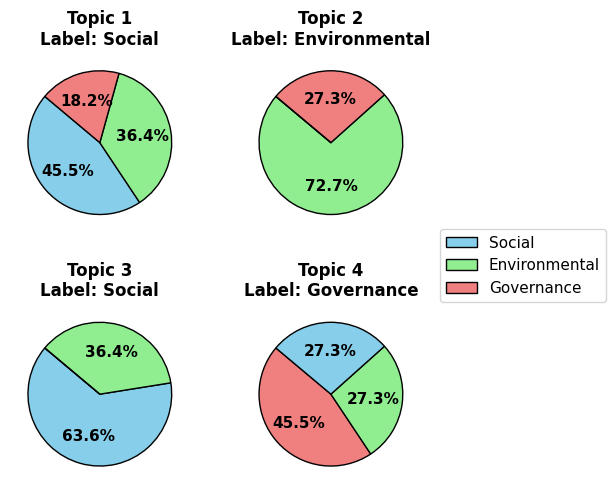

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

try:
    import seaborn as sns
    sns.reset_orig()
except Exception:
    pass
plt.rcdefaults()

data = {
    'Topic 1': {'Social': 5, 'Environmental': 4, 'Governance': 2},
    'Topic 2': {'Environmental': 8, 'Governance': 3, 'Social': 0},
    'Topic 3': {'Social': 7, 'Environmental': 4, 'Governance': 0},
    'Topic 4': {'Governance': 5, 'Environmental': 3, 'Social': 3}
}

colors = {'Social': 'skyblue', 'Environmental': 'lightgreen', 'Governance': 'lightcoral'}

fig, axs = plt.subplots(2, 2, figsize=(5.6, 5.6))
axs = axs.flatten()

def custom_autopct(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

for i, (topic, distribution) in enumerate(data.items()):
    distribution_colors = [colors[k] for k in distribution.keys()]
    axs[i].pie(
        distribution.values(),
        autopct=lambda pct: custom_autopct(pct),
        startangle=140,
        colors=distribution_colors,
        textprops={'fontsize': 11, 'weight': 'semibold'},
        wedgeprops={'linewidth': 1, 'edgecolor': 'black'}
    )
    maj = max(distribution, key=distribution.get)
    axs[i].set_title(f"{topic}\nLabel: {maj}", fontsize=12, weight='bold', pad=6)


fig.subplots_adjust(right=0.86, wspace=0.28, hspace=0.40)


labels = list(colors.keys())
handles = [Patch(facecolor=colors[l], edgecolor='black', label=l) for l in labels]
fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(0.88, 0.5),
    fontsize=11, frameon=True
)

plt.show()
